<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,completeness_score,accuracy_score,recall_score

In [2]:
X,y=load_breast_cancer(return_X_y=True)
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=44)

In [15]:
from sklearn.svm import SVC,SVR
model=SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [5]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0])

In [14]:
accuracy_score(y_test,y_pred)

0.956140350877193

In [7]:
recall_score(y_test,y_pred)

0.9733333333333334

In [8]:
X_vis=X[:,:2]
svm_vis=SVC()
svm_vis.fit(X_vis,y)

SVC()

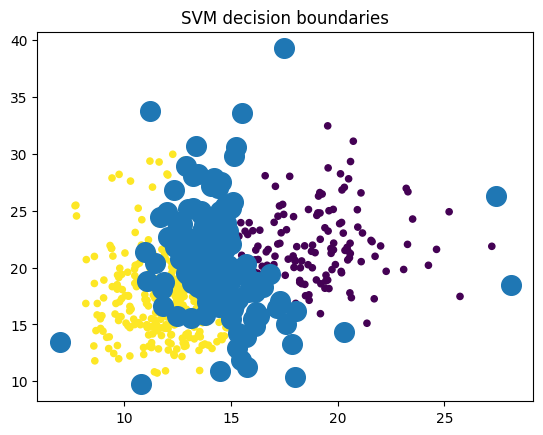

In [12]:
plt.scatter(X_vis[:,0],X_vis[:,1],c=y,s=20)
plt.scatter(svm_vis.support_vectors_[:,0],svm_vis.support_vectors_[:,1],s=200,label='support vectors')

plt.title("SVM decision boundaries")
plt.show()

In [23]:
model=SVC()
from sklearn.model_selection import GridSearchCV
param_grid={
    'C':[0.1,1,10,100],
    'kernel':['linear','rbf']
}
grid_search=GridSearchCV(
    estimator=model,
    param_grid=param_grid
)



In [24]:
grid_search.fit(X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']})

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

model = SVC()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    random_state=42
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'kernel': 'linear', 'C': 0.1}


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'svm__C': 0.1, 'svm__kernel': 'linear'}
0.9758241758241757
